In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/pratyushakar/rossmann-store-sales/store.csv
/kaggle/input/datasets/pratyushakar/rossmann-store-sales/train.csv
/kaggle/input/datasets/pratyushakar/rossmann-store-sales/test.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

In [3]:
# Path will look like this once you add the dataset via "Add Input"
train = pd.read_csv('/kaggle/input/datasets/pratyushakar/rossmann-store-sales/train.csv', low_memory=False)
store = pd.read_csv('/kaggle/input/datasets/pratyushakar/rossmann-store-sales/store.csv')

print(train.shape)
train.head()

(1017209, 9)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [4]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 5000
dates = pd.date_range('2023-01-01', periods=365)

df = pd.DataFrame({
    'date': np.random.choice(dates, n),
    'retailer_id': np.random.randint(1, 50, n),
    'product_id': np.random.randint(1, 30, n),
    'quantity_ordered': np.random.poisson(20, n),
    'unit_price': np.round(np.random.uniform(5, 100, n), 2),
})
df['revenue'] = df['quantity_ordered'] * df['unit_price']
df = df.sort_values('date').reset_index(drop=True)
df.head()

,date,retailer_id,product_id,quantity_ordered,unit_price,revenue
0,2023-01-01,48,22,22,44.26,973.72
1,2023-01-01,48,5,31,26.26,814.06
2,2023-01-01,48,9,22,30.84,678.48
3,2023-01-01,47,20,21,75.43,1584.03
4,2023-01-01,3,23,25,27.13,678.25


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              5000 non-null   datetime64[ns]
 1   retailer_id       5000 non-null   int64         
 2   product_id        5000 non-null   int64         
 3   quantity_ordered  5000 non-null   int64         
 4   unit_price        5000 non-null   float64       
 5   revenue           5000 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(3)
memory usage: 234.5 KB


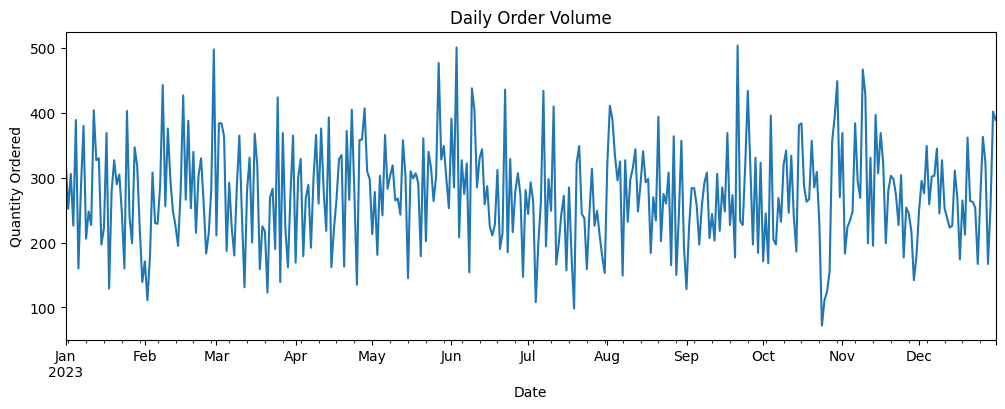

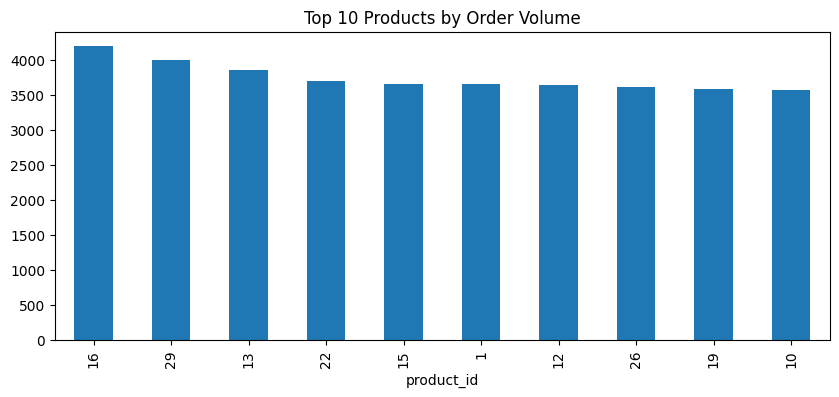

In [5]:
df.info()
df.describe()

# Sales trend over time
daily_sales = df.groupby('date')['quantity_ordered'].sum()
plt.figure(figsize=(12,4))
daily_sales.plot()
plt.title('Daily Order Volume')
plt.xlabel('Date'); plt.ylabel('Quantity Ordered')
plt.show()

# Top products by volume
top_products = df.groupby('product_id')['quantity_ordered'].sum().sort_values(ascending=False).head(10)
top_products.plot(kind='bar', figsize=(10,4), title='Top 10 Products by Order Volume')
plt.show()

In [6]:
df['date'] = pd.to_datetime(df['date'])
df['day_of_week'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month
df['week_of_year'] = df['date'].dt.isocalendar().week
df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)

# Aggregate to daily-per-product level (typical for demand forecasting)
daily = df.groupby(['date', 'product_id']).agg(
    quantity_ordered=('quantity_ordered', 'sum'),
    day_of_week=('day_of_week', 'first'),
    month=('month', 'first'),
    is_weekend=('is_weekend', 'first')
).reset_index()

# Lag features (past demand predicts future demand)
daily = daily.sort_values(['product_id', 'date'])
daily['lag_7'] = daily.groupby('product_id')['quantity_ordered'].shift(7)
daily['rolling_mean_7'] = daily.groupby('product_id')['quantity_ordered'].shift(1).rolling(7).mean()
daily = daily.dropna()
daily.head()

,date,product_id,quantity_ordered,day_of_week,month,is_weekend,lag_7,rolling_mean_7
164,2023-01-16,1,41,0,1,0,18.0,34.142857
173,2023-01-17,1,49,1,1,0,23.0,37.428571
256,2023-01-25,1,17,2,1,0,26.0,41.142857
272,2023-01-26,1,44,3,1,0,61.0,39.857143
304,2023-01-29,1,63,6,1,1,20.0,37.428571


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

features = ['day_of_week', 'month', 'is_weekend', 'lag_7', 'rolling_mean_7', 'product_id']
X = daily[features]
y = daily['quantity_ordered']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
model.fit(X_train, y_train)

preds = model.predict(X_test)
print("MAE:", mean_absolute_error(y_test, preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, preds)))

MAE: 9.847520238708741
RMSE: 12.540467621612823


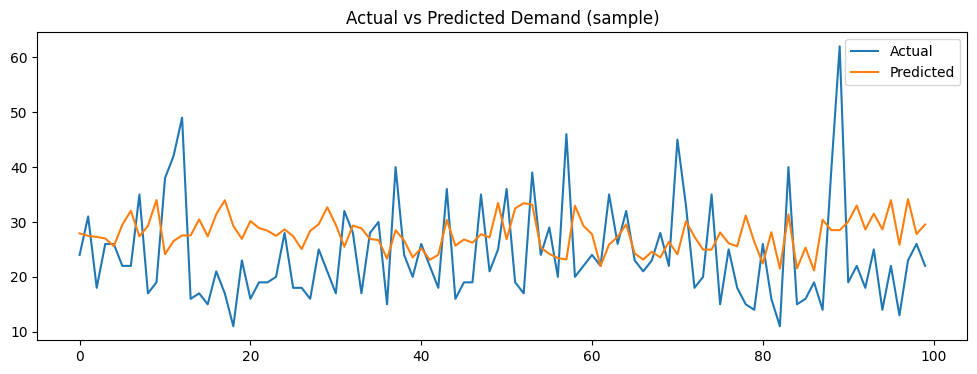

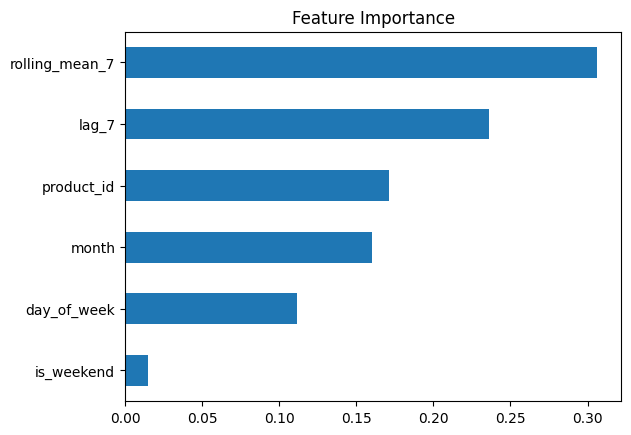

In [8]:
plt.figure(figsize=(12,4))
plt.plot(y_test.values[:100], label='Actual')
plt.plot(preds[:100], label='Predicted')
plt.legend()
plt.title('Actual vs Predicted Demand (sample)')
plt.show()

# Feature importance
importances = pd.Series(model.feature_importances_, index=features).sort_values()
importances.plot(kind='barh', title='Feature Importance')
plt.show()

In [9]:
import joblib
joblib.dump(model, '/kaggle/working/demand_forecast_model.pkl')
print("Model saved!")

Model saved!


In [10]:
def recommend_reorder(product_id, current_stock, days_of_cover=7):
    recent = daily[daily['product_id'] == product_id].tail(1)
    if recent.empty:
        return "No data"
    predicted_daily_demand = model.predict(recent[features])[0]
    reorder_qty = max(0, (predicted_daily_demand * days_of_cover) - current_stock)
    return round(reorder_qty)

print(recommend_reorder(product_id=5, current_stock=50))

120
